In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.linear_model import LinearRegression
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 4)

# Loading data

### Loading phénological and harvest historic dates

In [2]:
pheno = pd.read_excel('data/generated_pheno.xlsx', index_col=0)

pheno['Half-harvest'] = (pheno['Begin harvest'] + (pheno['End harvest'] - pheno['Begin harvest'])/2).dt.normalize()

display(pheno.head())

,Budburst,Begin flowering,End flowering,Begin véraison,Half véraison,Begin harvest,End harvest,Budburst - flowering interval,Flowering - véraison interval,Véraison - harvest interval,Growing season duration,Half-harvest
Année,,,,,,,,,,,,
1960,1960-03-18,1960-05-24,1960-05-30,1960-07-20,1960-08-02,1960-09-15,1960-10-06,67,64,44,181,1960-09-25
1961,1961-03-10,1961-05-16,1961-05-30,1961-07-23,1961-08-05,1961-09-17,1961-10-14,67,67,43,191,1961-09-30
1962,1962-04-14,1962-06-08,1962-06-17,1962-08-03,1962-08-16,1962-10-01,1962-10-22,55,60,46,170,1962-10-11
1963,1963-04-08,1963-06-13,1963-06-20,1963-08-13,1963-08-15,1963-10-01,1963-10-28,66,56,47,176,1963-10-14
1964,1964-04-06,1964-06-01,1964-06-14,1964-07-31,1964-08-13,1964-09-21,1964-10-20,56,60,39,168,1964-10-05


### Loading weather data and prices

In [11]:
weather_st_em = pd.read_csv('data/weather/generated_weather_st_em.csv', parse_dates=['Date']).set_index('Date')
prices_st_em = pd.read_excel('data/prices/generated_average_prices_st_em.xlsx', index_col=0)

weather_medoc = pd.read_csv('data/weather/generated_weather_pauillac.csv', parse_dates=['Date']).set_index('Date')
prices_medoc = pd.read_excel('data/prices/generated_average_prices_medoc.xlsx', index_col=0)

# Dropping useless features
weather_st_em = weather_st_em.drop(['Pl','Ps','Peff', 'SoilHum', 'Evap'], axis = 1)
weather_medoc = weather_medoc.drop(['Pl','Ps','Peff', 'SoilHum', 'Evap'], axis = 1)

# Adding useful features
weather_st_em['Frost'] = (weather_st_em['Tn'] < 0).astype(int) * (-weather_st_em['Tn'])
weather_medoc['Frost'] = (weather_medoc['Tn'] < 0).astype(int) * (-weather_medoc['Tn'])

weather_st_em['DTR'] = weather_st_em['Tx'] - weather_st_em['Tn']
weather_medoc['DTR'] = weather_medoc['Tx'] - weather_medoc['Tn']

weather_st_em['Stress'] = 0.5*weather_st_em['ETP'] - weather_st_em['P']
weather_medoc['Stress'] = 0.5*weather_medoc['ETP'] - weather_medoc['P']

weather_st_em['GDD10'] = ((weather_st_em['Tx']+weather_st_em['Tx'])/2 > 10).astype(int) * ((weather_st_em['Tx']+weather_st_em['Tx'])/2 - 10)
weather_medoc['GDD10'] = ((weather_medoc['Tx']+weather_medoc['Tx'])/2 > 10).astype(int) * ((weather_medoc['Tx']+weather_medoc['Tx'])/2 - 10)

# Reordering columns for lisibility of the graphs
weather_st_em = weather_st_em[['Tn', 'Tm', 'Tx', 'DTR', 'Wind', 'Sun', 'ETP', 'Stress', 'P', 'Frost', 'GDD10']]
weather_medoc = weather_medoc[['Tn', 'Tm', 'Tx', 'DTR', 'Wind', 'Sun', 'ETP', 'Stress', 'P', 'Frost', 'GDD10']]

ORIG_WEATHER_FEATURES = list(weather_medoc.columns)

display(weather_medoc.head())

,Tn,Tm,Tx,DTR,Wind,Sun,ETP,Stress,P,Frost,GDD10
Date,,,,,,,,,,,
1960-01-01,9.7,11.9,13.5,3.8,5.8,394.8,1.1,-8.55,9.1,-0.0,3.5
1960-01-02,11.2,12.4,14.0,2.8,8.4,333.7,1.4,-6.80,7.5,-0.0,4.0
1960-01-03,11.1,12.3,13.0,1.9,4.7,254.8,0.8,-1.60,2.0,-0.0,3.0
1960-01-04,12.4,12.9,13.9,1.5,1.5,363.0,0.7,0.35,0.0,-0.0,3.9
1960-01-05,9.9,10.6,11.7,1.8,2.4,331.9,0.4,0.20,0.0,-0.0,1.7


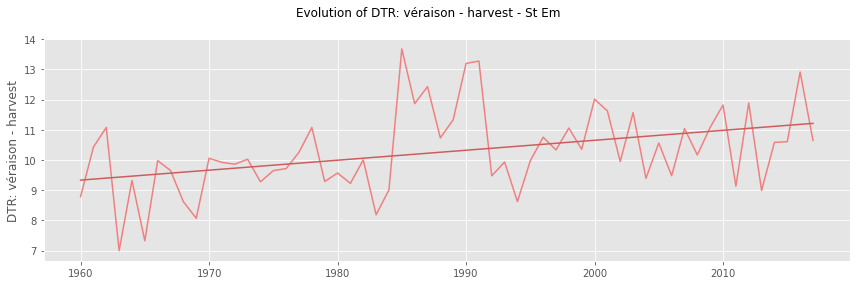

,Tn: budburst - flowering,Tn: flowering,Tn: flowering - véraison,Tn: véraison - harvest,Tn: harvest,Tm: budburst - flowering,Tm: flowering,Tm: flowering - véraison,Tm: véraison - harvest,Tm: harvest,...,GDD10: budburst - flowering,GDD10: flowering,GDD10: flowering - véraison,GDD10: véraison - harvest,GDD10: harvest,Growing Season Tm,Winter Rain,Floraison date,GDD10,Stress
1960,9.054412,14.485714,15.455385,14.993333,13.190909,12.882353,18.628571,19.030769,18.444444,15.513636,...,447.8,87.2,821.1,551.9,181.4,16.948634,0.000000,145,1989.8,-77.35
1961,8.794118,10.453333,15.214706,15.502273,14.767857,12.645588,14.573333,18.823529,19.543182,18.392857,...,449.9,132.3,862.4,613.7,352.7,17.506011,5.003289,136,2249.1,94.40
1962,9.800000,14.020000,15.606557,14.308511,11.209091,13.421429,18.350000,19.372131,18.642553,14.913636,...,389.3,125.1,806.0,607.0,202.1,16.615847,3.417763,159,2111.4,106.75
1963,10.750746,14.475000,15.715789,14.208333,11.385714,13.837313,17.250000,19.056140,16.883333,14.575000,...,484.5,79.9,720.2,472.7,230.4,16.104372,2.480921,164,1961.5,-146.10
1964,10.868421,15.400000,15.845902,16.165000,12.323333,14.382456,18.335714,19.865574,19.725000,15.126667,...,458.0,164.0,855.7,537.0,253.1,17.648087,1.697386,153,2232.2,100.05


In [12]:
def create_df(weather):
    vintages = list(pheno.index)
    
    df = pd.DataFrame(index = vintages)
    
    events = ['budburst', 'flowering', 'véraison', 'harvest']
    
    intervals = {
        'budburst - flowering' : ['Budburst', 'Begin flowering'],
        'flowering' : ['Begin flowering', 'End flowering'],
        'flowering - véraison' : ['End flowering', 'Half véraison'],
        'véraison - harvest': ['Half véraison', 'Begin harvest'],
        'harvest' : ['Begin harvest', 'End harvest']
    }
    
    # Adding all base features, declined on all intervals
    for feature in ORIG_WEATHER_FEATURES:
        subfeatures_list = [feature + ': '+ interval for interval in intervals.keys()]
            
        for subfeature in subfeatures_list:
            df[subfeature] = 0
    
        for interval in intervals.keys():
            feature_name = feature + ': '+ interval
            for vintage in vintages:
                date_begin, date_end = pheno.loc[vintage, intervals[interval][0]], pheno.loc[vintage, intervals[interval][1]]
                if feature in ['Hail', 'P', 'Wind', 'ETP', 'GDD10', 'Heavy Rain']:
                    df.loc[vintage, feature_name] = weather.loc[date_begin:date_end, feature].sum()  
                    
                #elif feature == 'GDD':
                #    date_debourrement = pheno.loc[vintage, 'debourrement']
                #    df.loc[vintage, feature_name] = weather.loc[date_debourrement:date_end, feature].sum()           
                else:
                    df.loc[vintage, feature_name] = weather.loc[date_begin:date_end, feature].mean()
                    
    df['Growing Season Tm'] = np.nan
    for vintage in vintages: # do not include first vintage
        date_begin = datetime.date(vintage, 4, 1) # Begin on April 1
        date_end = datetime.date(vintage , 9, 30) # End in September

        df.loc[vintage, 'Growing Season Tm'] = weather.loc[date_begin:date_end, 'Tm'].mean()
    #plt.plot(df['Growing Season Tm'])
    #plt.suptitle('Growing Season Tm')
    #plt.show()
    
    
    ### Adding other features ###
    
    df['Winter Rain'] = 0
    for vintage in vintages[1:]: # do not include first vintage
        date_begin = datetime.date(vintage - 1, 10, 1) # Begin on October 1, previous year
        date_end = datetime.date(vintage , 3, 1) # End mid March
        df.loc[vintage, 'Winter Rain'] += weather.loc[date_begin:date_end, 'P'].mean()
    
    df['Floraison date'] = pheno['Begin flowering'].dt.dayofyear
    
    df['GDD10'] = 0
    for vintage in vintages: # do not include first vintage
        date_begin = datetime.date(vintage, 4, 1)
        date_end = pheno.loc[vintage, 'End harvest']
        df.loc[vintage, 'GDD10'] += (weather.loc[date_begin:date_end, 'GDD10']).sum()
        
    # Dropping Frost in the periods where it is nearly always 0
    df = df.drop(['Frost: flowering - véraison', 'Frost: véraison - harvest', 'Frost: harvest', 'Frost: flowering'], axis=1)
    
    df['Stress'] = 0.5*(df['ETP: flowering - véraison'] + df['ETP: véraison - harvest']) - (df['P: flowering - véraison'] + df['P: véraison - harvest'])
    
    return df

df_st_em = create_df(weather_st_em)
df_medoc = create_df(weather_medoc)


plt.figure(figsize=(12,4))
linreg = LinearRegression()
linreg.fit(np.array(list(df_st_em.index)).reshape(-1,1), df_st_em[['DTR: véraison - harvest']])
sns.lineplot(x = df_st_em.index, y = df_st_em['DTR: véraison - harvest'], color='lightcoral')
plt.plot(df_st_em.index, linreg.predict(np.array(list(df_st_em.index)).reshape(-1,1)), color='indianred')
plt.suptitle('Evolution of DTR: véraison - harvest - St Em')
plt.tight_layout()
plt.show()

display(df_medoc.head())

#### Load prices

Only goal of unskewing prices is to put them closer to the 0-1 range, but any transformation that leaves their order untouched does not change the predictive power. HOWEVER, it probably helps training the reg model.

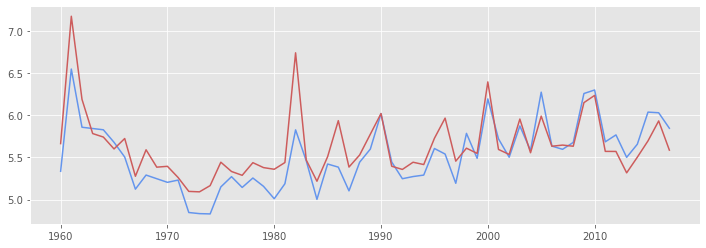


St Emilion:


,skew,kurtosis
Log price,0.432361,-0.108372



Medoc :


,skew,kurtosis
Log price,1.774388,4.532202


In [14]:
from sklearn.preprocessing import PowerTransformer
from scipy.stats import skew
from sklearn.linear_model import LinearRegression


price_st_em = np.log(prices_st_em['Average price']).loc[1960:]
price_medoc = np.log(prices_medoc['Average price']).loc[1960:]
plt.plot(price_st_em, color='cornflowerblue')
plt.plot(price_medoc, color='indianred')
plt.show()

### Yeo Johnson transofrmation, in order to unskew prices. Finally not kept because didn't improve perf ###

#price = np.log(price)

#pt = PowerTransformer()
#price = pt.fit_transform(np.log(prices['Price'].loc[1961:]).values.reshape(-1,1))/2

#print(df.agg(['skew', 'kurtosis']).T)

df_st_em['Log price'] = price_st_em
df_medoc['Log price'] = price_medoc

print('\nSt Emilion:')
display(df_st_em[['Log price']].agg(['skew', 'kurtosis']).T)

print('\nMedoc :')
display(df_medoc[['Log price']].agg(['skew', 'kurtosis']).T)

#### Output to Excel

In [ ]:
df_st_em.to_excel('data/generated_features_st_em.xlsx')
df_medoc.to_excel('data/generated_features_medoc.xlsx')

# Exploration: display correlations heatmap

Saint-Emilion:


Log price                     1.00
DTR: véraison - harvest       0.61
Stress                        0.58
P: flowering                  0.58
Tn: budburst - flowering      0.55
Stress: flowering             0.53
Stress: véraison - harvest    0.53
GDD10                         0.52
Wind: flowering               0.52
Tm: budburst - flowering      0.48
Name: Log price, dtype: float64


Medoc:


Log price                      1.00
Stress: véraison - harvest     0.62
Sun: véraison - harvest        0.59
DTR: véraison - harvest        0.59
Stress                         0.54
P: véraison - harvest          0.54
ETP: véraison - harvest        0.42
P: flowering                   0.41
Wind: harvest                  0.40
GDD10: budburst - flowering    0.38
Name: Log price, dtype: float64

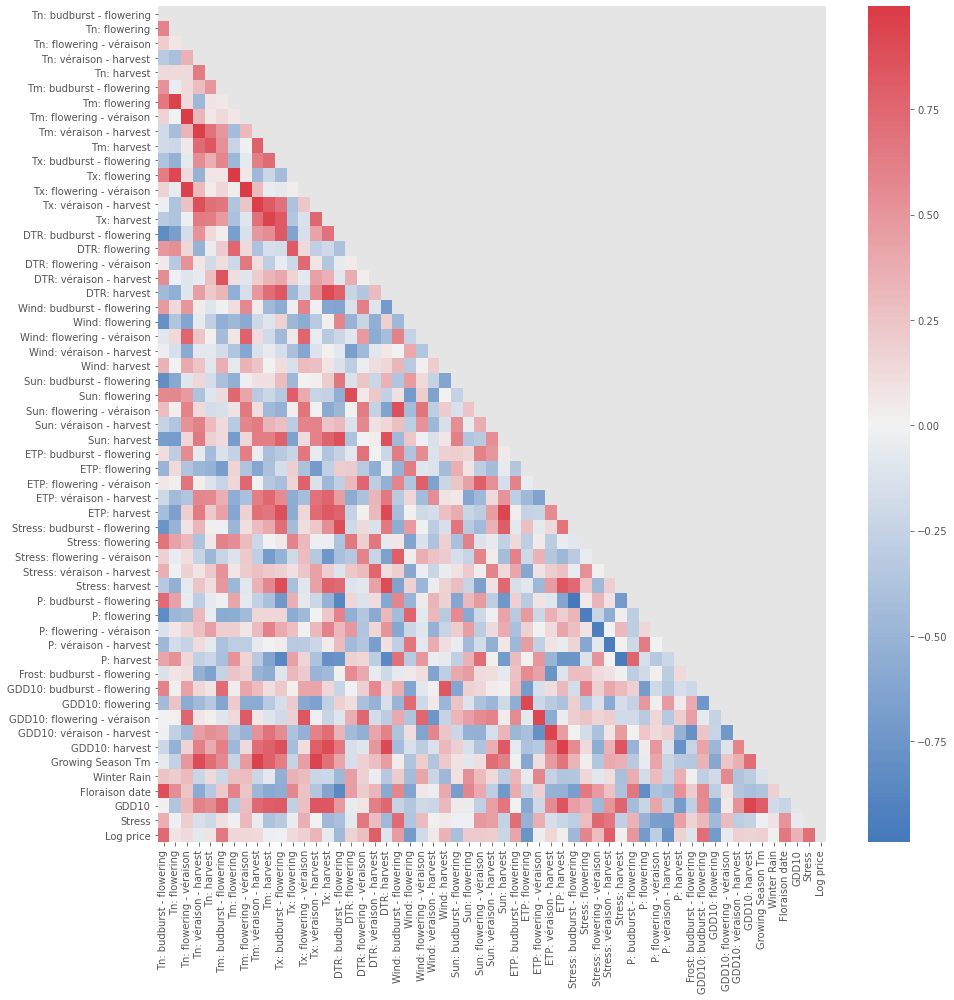

In [16]:
# Display top correlated features in absolute value
print('Saint-Emilion:')
display(df_st_em.loc[1994:2017, :].reset_index().corr()['Log price'].abs().nlargest(10).round(2))
print('\nMedoc:')
display(df_medoc.loc[1994:2017, :].reset_index().corr()['Log price'].abs().nlargest(10).round(2))

plt.figure(figsize=(14,14))
mask = np.triu(np.ones_like(pd.concat((df_st_em.loc[1994:, :], df_st_em.loc[1994:, :]), axis=0).corr()))
cmap = sns.diverging_palette(250, 10, as_cmap=True)

# Heatmap of correlations for the two dataframes, combined
sns.heatmap(pd.concat((df_st_em.loc[1994:2003, :], df_st_em.loc[1994:2003, :]), axis=0).corr(), mask=mask, cmap=cmap)

# Heatmap of correlations for Saint-Émilion only
#sns.heatmap(df_st_em.loc[1994:2017, :].corr(), mask=mask, cmap=cmap)

plt.tight_layout()
plt.savefig('views/heatmap.png')
plt.show()

#### Top features: ['Stress',  'DTR: véraison - harvest', 'P: flowering']

# Regression

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge, Lasso, LinearRegression

def baseline_OLS_regression(X, y, first, last, width, fixed_1994):
    
    X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
    if width == None:
        predictions = pd.DataFrame(index=range(first + 20, last), columns=['Log Price'])
        coefficients = pd.DataFrame(0, index=range(first, last- 20 +1), columns = ['const']+X.columns.to_list())
        year_range = range(first, last - 20 + 1)

    else:
        predictions = pd.DataFrame(index=range(first + width, last), columns=['Log Price'])
        coefficients = pd.DataFrame(0, index=range(first, last- width +1), columns = ['const']+X.columns.to_list())
        year_range = range(first, last - width + 1)

        
    for year in year_range:
        if width == None: #Want to train with a minimal window of size 20
            oldest_vintage = first
            newest_vintage = year +  20 - 1
            
        else:
            oldest_vintage = year
            newest_vintage = year +  width - 1
        
        y_train = y.loc[oldest_vintage:newest_vintage, 'Log price']
        X_train = X.loc[oldest_vintage-first:newest_vintage-first,:]
        
        mod = LinearRegression()
        mod.fit(X_train, y_train.values)
        coefs = mod.coef_
        coefficients.loc[year, X_train.columns] = coefs
        coefficients.loc[year, 'const'] = mod.intercept_
        
        X_test = X.loc[newest_vintage-first+1:newest_vintage-first+1,:]
        
        if fixed_1994:
            if year==1994- width -1:
                mod_base = mod
                
            if year >=1994- width -1:
                print(year+ width +1, ': using 1993 model.')
                predictions.loc[newest_vintage+1] = mod_base.predict(X_test.values)[0]

            else:
                predictions.loc[newest_vintage+1] = mod.predict(X_test.values)[0]

        else:
            predictions.loc[newest_vintage+1] = mod.predict(X_test.values)[0]
    return coefficients, predictions.loc[1994:]

def baseline_OLS_regression_combined(X_medoc, y_medoc, X_st_em, y_st_em, first, last, width, fixed_1994):
    X_medoc = pd.DataFrame(StandardScaler().fit_transform(X_medoc), columns=X_medoc.columns)
    X_st_em = pd.DataFrame(StandardScaler().fit_transform(X_st_em), columns=X_st_em.columns)
    
    if width == None:
        predictions_st_em = pd.DataFrame(index=range(first + width, last), columns=['Log Price'])
        predictions_medoc = pd.DataFrame(index=range(first + width, last), columns=['Log Price'])
        year_range = range(first, last - 20 + 1)

    if width != None:
        predictions_st_em = pd.DataFrame(index=range(first + 20, last), columns=['Log Price'])
        predictions_medoc = pd.DataFrame(index=range(first + 20, last), columns=['Log Price'])
        year_range = range(first, last - width + 1)

    for year in year_range:
        if width == None: # Want to train with a minimal window of size 20
            oldest_vintage = first
            newest_vintage = year +  20 - 1
            
        else:
            oldest_vintage = year
            newest_vintage = year +  width - 1

        y_medoc_train = y_medoc.loc[oldest_vintage:newest_vintage, 'Log price']
        y_st_em_train = y_st_em.loc[oldest_vintage:newest_vintage, 'Log price']
        y_train = np.concatenate((y_medoc_train, y_st_em_train), axis=0)
        
        X_medoc_train = np.concatenate((X_medoc.loc[oldest_vintage-first:newest_vintage-first,:].values, np.ones((len(X_medoc.loc[oldest_vintage-first:newest_vintage-first,:]), 1))), axis=1)
        X_st_em_train = np.concatenate((X_st_em.loc[oldest_vintage-first:newest_vintage-first,:].values, np.zeros((len(X_medoc.loc[oldest_vintage-first:newest_vintage-first,:]), 1))), axis=1)
        X_train  = np.concatenate((X_medoc_train, X_st_em_train), axis = 0)
        
        mod = LinearRegression()
        mod.fit(X_train, y_train)
        
        X_medoc_test = np.concatenate((X_medoc.loc[newest_vintage-first+1:newest_vintage-first+1,:].values, np.ones((1,1))), axis=1)
        X_st_em_test = np.concatenate((X_st_em.loc[newest_vintage-first+1:newest_vintage-first+1,:].values, np.ones((1,1))), axis=1)

        predictions_medoc.loc[newest_vintage+1] = mod.predict(X_medoc_test)[0]
        predictions_st_em.loc[newest_vintage+1] = mod.predict(X_st_em_test)[0]

    return predictions_medoc, predictions_st_em

In [25]:
def score_predictions(predictions, y):
    spearman_r = round(spearmanr(y.loc[1994:2017], predictions.loc[1994:2017])[0], 2)
    mae = round(np.mean(np.abs(predictions.loc[1994:2017].values- y.loc[1994:2017].values)), 2)
    r2 = round(r2_score(y.loc[1994:2017].values, predictions.loc[1994:2017].values), 2)
    return spearman_r, r2, mae

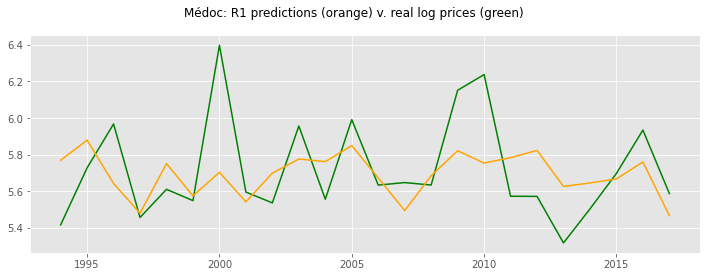

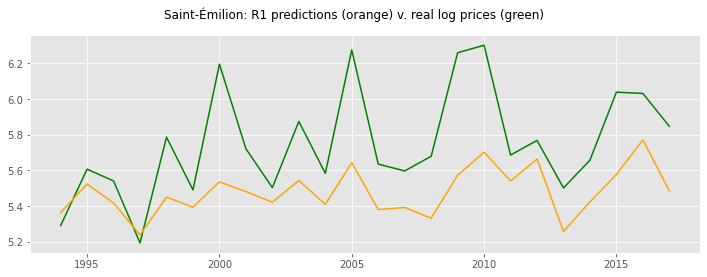

,"Simple, fixed begin","Simple, sliding windows","Combined, sliding windows"
Médoc: SpearmanR,0.34,0.53,0.55
Saint-Émilion: SpearmanR,0.84,0.84,0.74
Médoc: R2,0.12,0.26,0.32
Saint-Émilion: R2,-0.35,0.13,0.37
Médoc: MAE,0.23,0.25,0.25
Saint-Émilion: MAE,0.33,0.35,0.29


In [33]:
results_df = pd.DataFrame(index = [
    'Médoc: SpearmanR',
    'Saint-Émilion: SpearmanR',
    'Médoc: R2',
    'Saint-Émilion: R2',
    'Médoc: MAE',
    'Saint-Émilion: MAE'
])

# Loading data

df_medoc = df_medoc.loc[first:last]
X_medoc = df_medoc.drop('Log price', axis=1)[['Stress', 'P: flowering', 'DTR: véraison - harvest']]
y_medoc = df_medoc[['Log price']]

df_st_em = df_st_em.loc[first:last]
X_st_em = df_st_em.drop('Log price', axis=1)[['Stress', 'P: flowering', 'DTR: véraison - harvest']]
y_st_em = df_st_em[['Log price']]

### R1 : simple regression, training windows begins at first vintage available, not combined training. ###
results_df['Simple, fixed begin'] = 0

coefficients_medoc, predictions_medoc = baseline_OLS_regression(X_medoc, y_medoc, 1960, 2017, None, fixed_1994 = False)
coefficients_st_em, predictions_st_em = baseline_OLS_regression(X_st_em, y_st_em, 1960, 2017, None, fixed_1994 = False)

results_df.iloc[0::2, 0] = score_predictions(predictions_medoc, df_medoc['Log price'])
results_df.iloc[1::2, 0] = score_predictions(predictions_st_em, df_st_em['Log price'])

plt.plot(y_medoc.loc[1994:], color = 'green')
plt.plot(predictions_medoc, color = 'orange')
plt.suptitle('Médoc: R1 predictions (orange) v. real log prices (green)')

plt.plot(y_st_em.loc[1994:], color = 'green')
plt.plot(predictions_st_em, color = 'orange')
plt.suptitle('Saint-Émilion: R1 predictions (orange) v. real log prices (green)')
plt.show()
### R2 : simple regression, sliding windows, not combined training. ###
results_df['Simple, sliding windows'] = 0

coefficients_medoc, predictions_medoc = baseline_OLS_regression(X_medoc, y_medoc, 1960, 2017, 20, fixed_1994 = False)
coefficients_st_em, predictions_st_em = baseline_OLS_regression(X_st_em, y_st_em, 1960, 2017, 20, fixed_1994 = False)

results_df.iloc[0::2, 1] = score_predictions(predictions_medoc, df_medoc['Log price'])
results_df.iloc[1::2, 1] = score_predictions(predictions_st_em, df_st_em['Log price'])

### R3 : simple regression, sliding windows. Combined training. ###
results_df['Combined, sliding windows'] = 0

predictions_medoc, predictions_st_em = model_tester_combined(X_medoc, y_medoc, X_st_em, y_st_em, 1960, 2017, 20, fixed_1994 = False)

results_df.iloc[0::2, 2] = score_predictions(predictions_medoc, df_medoc['Log price'])
results_df.iloc[1::2, 2] = score_predictions(predictions_st_em, df_st_em['Log price'])
display(results_df)
results_df.to_excel('tables/regression_results.xlsx')

# Appendix: PCA

This does not work better, and it makes the model less explainable, therefore it is not a good solution.

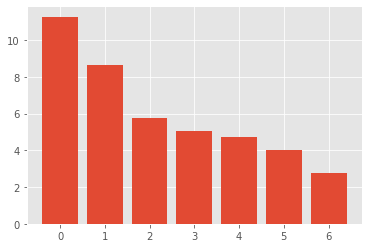

,0,1,2,3,4,5,6
1980,-4.354726,1.794528,0.970380,0.180457,1.694633,-0.256372,-1.641731
1981,0.832289,-2.561261,-1.263189,1.072136,0.367313,-0.680976,-1.267017
1982,2.985240,-0.121465,-2.080035,-0.772342,-1.123292,3.158297,2.591032
1983,1.130416,2.353051,2.173226,-0.231008,-3.864273,-0.755364,-1.200368
1984,-1.813309,-1.169158,-1.870055,-2.802077,1.346254,-1.121126,-0.302894


In [82]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create scaler: scaler
scaler = StandardScaler()

# Create a PCA instance: pca
pca = PCA(n_components=7)

# Create pipeline: pipeline
pipeline = make_pipeline(scaler,pca)

X = df.drop('Log price', axis=1).loc[1961:1994]

X = pd.DataFrame(StandardScaler().fit_transform(X), index=X.index, columns=X.columns).loc[1980:,:]


pipeline.fit(X.dropna(axis=0))
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_)
plt.show()

X = X.dropna(axis=0)
X2 = pd.DataFrame(pca.transform(X), index=X.index)
display(X2.head())

In [83]:
from mpl_toolkits.mplot3d import Axes3D
%matplotlib qt


def myplot(score,coeff,labels=None):
    xs = score[:,0]
    ys = score[:,2]
    n = coeff.shape[0]
    #plt.scatter(xs ,ys) #without scaling
    for i in range(len(labels)):
        plt.arrow(0, 0, coeff[0,i], coeff[1,i],color = 'r',alpha = 0.5)
        if labels is None:
            plt.text(coeff[0,i]* 1.10, coeff[1,i] * 1.10, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            plt.text(coeff[0,i]* 1.10, coeff[1,i] * 1.10, labels[i], color = 'g', ha = 'center', va = 'center')

            
fig = plt.figure(figsize=(13,13))
ax = fig.add_subplot(111, projection='3d')

coef = pca.components_

ax.scatter(coef[0,:] , coef[1, :] , coef[2, :])

for i in range(len(X.columns)):
    ax.text(coef[0,i]+np.mean(coef[0,:])/1000,coef[1,i]+np.mean(coef[1,:])/1000 ,coef[2,i]+np.mean(coef[2,:])/1000, list(X.columns)[i], zdir=None)

# 